# Ensemble Kaggle branch

In this notebook we process te image input and train an ensemble model with 
different arquitectures

In [ ]:
# --- Imports & config ---
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
import timm
import os
import copy
import matplotlib.pyplot as plt
import time, torch
from torch.utils.data import WeightedRandomSampler, DataLoader
from tqdm import tqdm
from torch import amp
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import sys
sys.path.append("../utils")
from utils import create_balanced_split , ISIC_Multimodal_Dataset

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths (adjust if needed)
DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")
TRAIN_META_CSV = DATA_DIR / "train-metadata.csv"
TEST_META_CSV  = DATA_DIR / "test-metadata.csv"
TRAIN_H5_PATH  = DATA_DIR / "train-image.hdf5"
TEST_H5_PATH   = DATA_DIR / "test-image.hdf5"

# Columns
ID_COL      = "isic_id"
TARGET_COL  = "target"
GROUP_COL   = "patient_id"

RANDOM_STATE = 42
N_SPLITS = 5

print(TRAIN_META_CSV.resolve())
print(TRAIN_H5_PATH.resolve())

Using device: cuda
/home/pawn/Desktop/deep_learning/ISIC_DL/data/train-metadata.csv
/home/pawn/Desktop/deep_learning/ISIC_DL/data/train-image.hdf5


## Load and analyze the data

Because of the extreme class imbalance in the dataset (approximately 0.01 vs 99.99), we follow two strategies. First, we limit the ratio of healthy lesions included during training: instead of using the full 400,000 benign images, we use a controlled ratio of 25 benign samples per malignant sample. Second, we apply targeted data augmentation to malignant class (class 1) examples to increase their effective variability and reduce overfitting.

For class 1 (malignant lesions), we apply medically appropriate augmentations inspired by the recommendations in Mahbod et al., *"Effects of augmentation strategies on skin lesion classification"* (2019). Their study demonstrates that carefully selected geometric and photometric transformations improve melanoma classification performance while avoiding unrealistic distortions.

Below is a summary of the augmentation pipeline used in this work.

### Data Augmentation for Skin Lesion Classification (ISIC)

To improve model generalization in skin lesion classification, we apply a set of medically validated data augmentations. These transformations simulate real-world acquisition variability, including differences in camera systems, zoom levels, lighting conditions, focus, rotation, and minor occlusions such as hair or ruler marks.

A brief explanation of each augmentation follows.

1. Resize → RandomResizedCrop
Images are first resized for consistent input dimensions. A random crop (90%–100% of the area) is then extracted.
*Purpose*: Simulates variation in zoom and framing across dermoscopy systems.


2. Random Rotation (±15°)
Applies small rotations without distorting the lesion structure.
*Purpose*: Lesions do not have a fixed orientation; rotation increases representation diversity.


3. Horizontal Flip
Mirrors the image horizontally.
*Purpose*: Human anatomy is largely symmetric; lesion appearance remains valid under flipping.


4. ColorJitter
Applies light variations in brightness, contrast, saturation, and hue.
*Purpose*: Models differences across dermatoscopes, lighting conditions, and skin tones.

5. RandomAdjustSharpness
Applies slight sharpening at random.
*Purpose*: Simulates variability in optical focus and imaging quality.

6. Gaussian Blur
Adds small blur variations.
*Purpose*: Reproduces the behavior of different dermoscopic camera systems.

7. RandomErasing
Erases a small random region of the image.
*Purpose*: Simulates occlusions such as hair, bubbles, ruler artifacts, or pen marks.

8. Normalize (ImageNet mean/std)
Standard normalization used with ImageNet-pretrained CNNs.

#### Scientific Support

These augmentations are supported by dermatology-focused studies, particularly:

**Mahbod et al., "Effects of augmentation strategies on skin lesion classification" (2019)**  
This work shows that:
- light geometric transformations,  
- controlled color perturbations,  
- blur and sharpness adjustments,  
- and occlusion-based augmentations  
consistently improve melanoma classification accuracy across ISIC datasets.

Link: https://arxiv.org/abs/1910.05351

---

Together, these augmentations increase robustness, reduce overfitting, and help compensate for the limited number of malignant samples in the dataset.


In [72]:
import torchvision.transforms as T


class DermoscopyAugmentation:
    """
    Scientific-grade augmentation pipeline for skin lesion classification.
    Designed based on augmentation strategies validated in ISIC Challenge papers.
    """

    @staticmethod
    def get_dataAugmentation_transforms():
        """Training augmentations (medically validated)"""
        return T.Compose([
            T.RandomResizedCrop(224,scale=(0.95, 1.0),ratio=(0.9, 1.1)),
            T.RandomApply([T.ColorJitter(brightness=0.1, contrast=0.1)],p=0.75),
            T.RandomRotation(10),
            T.RandomApply([T.GaussianBlur(kernel_size=5)],p=0.3),
            T.RandomHorizontalFlip(p=0.5),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            T.RandomErasing(p=0.05, scale=(0.01, 0.05), ratio=(0.3, 3.3))
        ])

    @staticmethod
    def get_training_transforms():
        """Aggressive but medically-sound training augmentations"""
        return T.Compose([
            T.Resize(256),
            T.CenterCrop(224),

            T.RandomRotation(10),

            T.ColorJitter(
                brightness=0.05,
                contrast=0.05,
                saturation=0.05,
                hue=0.01,
            ),

            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),

            # optional but ok
            T.RandomErasing(p=0.05, scale=(0.01, 0.05), ratio=(0.3, 3.3)),
        ])
    
    @staticmethod
    def get_validation_transforms():
        """Conservative validation transforms"""
        return T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

In [73]:
from utils import get_best_metadata, MetadataProcessor

# 1º Create a split of train and validation balanced
# we dont need all the images
NEG_RATIO = 40      # 25:1
train_df, val_df, df_balanced = create_balanced_split(
    TRAIN_META_CSV,
    neg_multiplier=NEG_RATIO,      # conservative ratio of 25:1 
    val_frac=0.2            # split a 20% of train to validation
)

# 2º Create the augmented test and validation datasets trasforming the data
# with the following methods

augmentation_trans = DermoscopyAugmentation.get_dataAugmentation_transforms()
base_trans = DermoscopyAugmentation.get_training_transforms()
validation_trans = DermoscopyAugmentation.get_training_transforms()

# get the best metadata features analized with PCA common between test and train
test_df = pd.read_csv(TEST_META_CSV)
best_features = get_best_metadata(train_df, test_df, num_feat=50, verbose=True)
metadata_processor = MetadataProcessor(best_features)
metadata_processor.fit(pd.read_csv(TRAIN_META_CSV))

train_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TRAIN_H5_PATH,
    metadata_df=train_df,
    data_augmentation_trans=augmentation_trans,
    image_transform=validation_trans,
    augment_positives=True,
    metadata_processor=metadata_processor
)

val_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TRAIN_H5_PATH,
    metadata_df=val_df,
    image_transform=validation_trans,
    metadata_processor=metadata_processor
)

test_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=TEST_H5_PATH,
    metadata_df=test_df,
    image_transform=validation_trans,
    metadata_processor=metadata_processor
)

/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:60: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadataCSV_path)


Positives: 343
Negatives available: 400616
Negatives to sample: 13720

Balanced dataset size: 14063
target
0    13720
1      343
Name: count, dtype: int64

✔ Using all metadata features


/tmp/ipykernel_4300/4264088597.py:23: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_processor.fit(pd.read_csv(TRAIN_META_CSV))


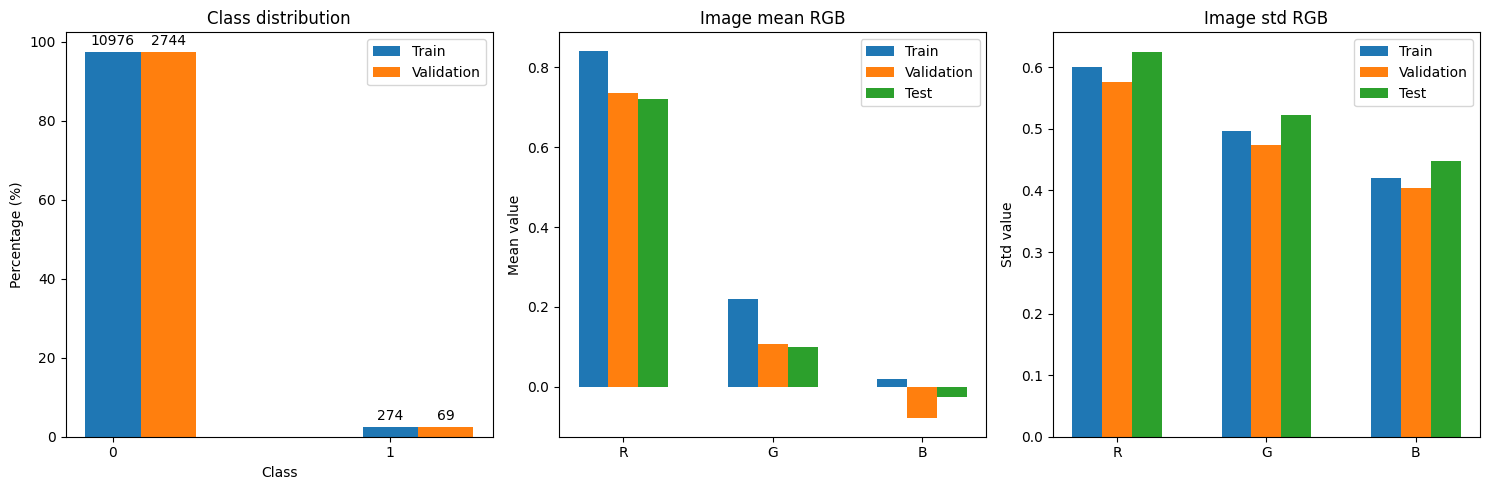

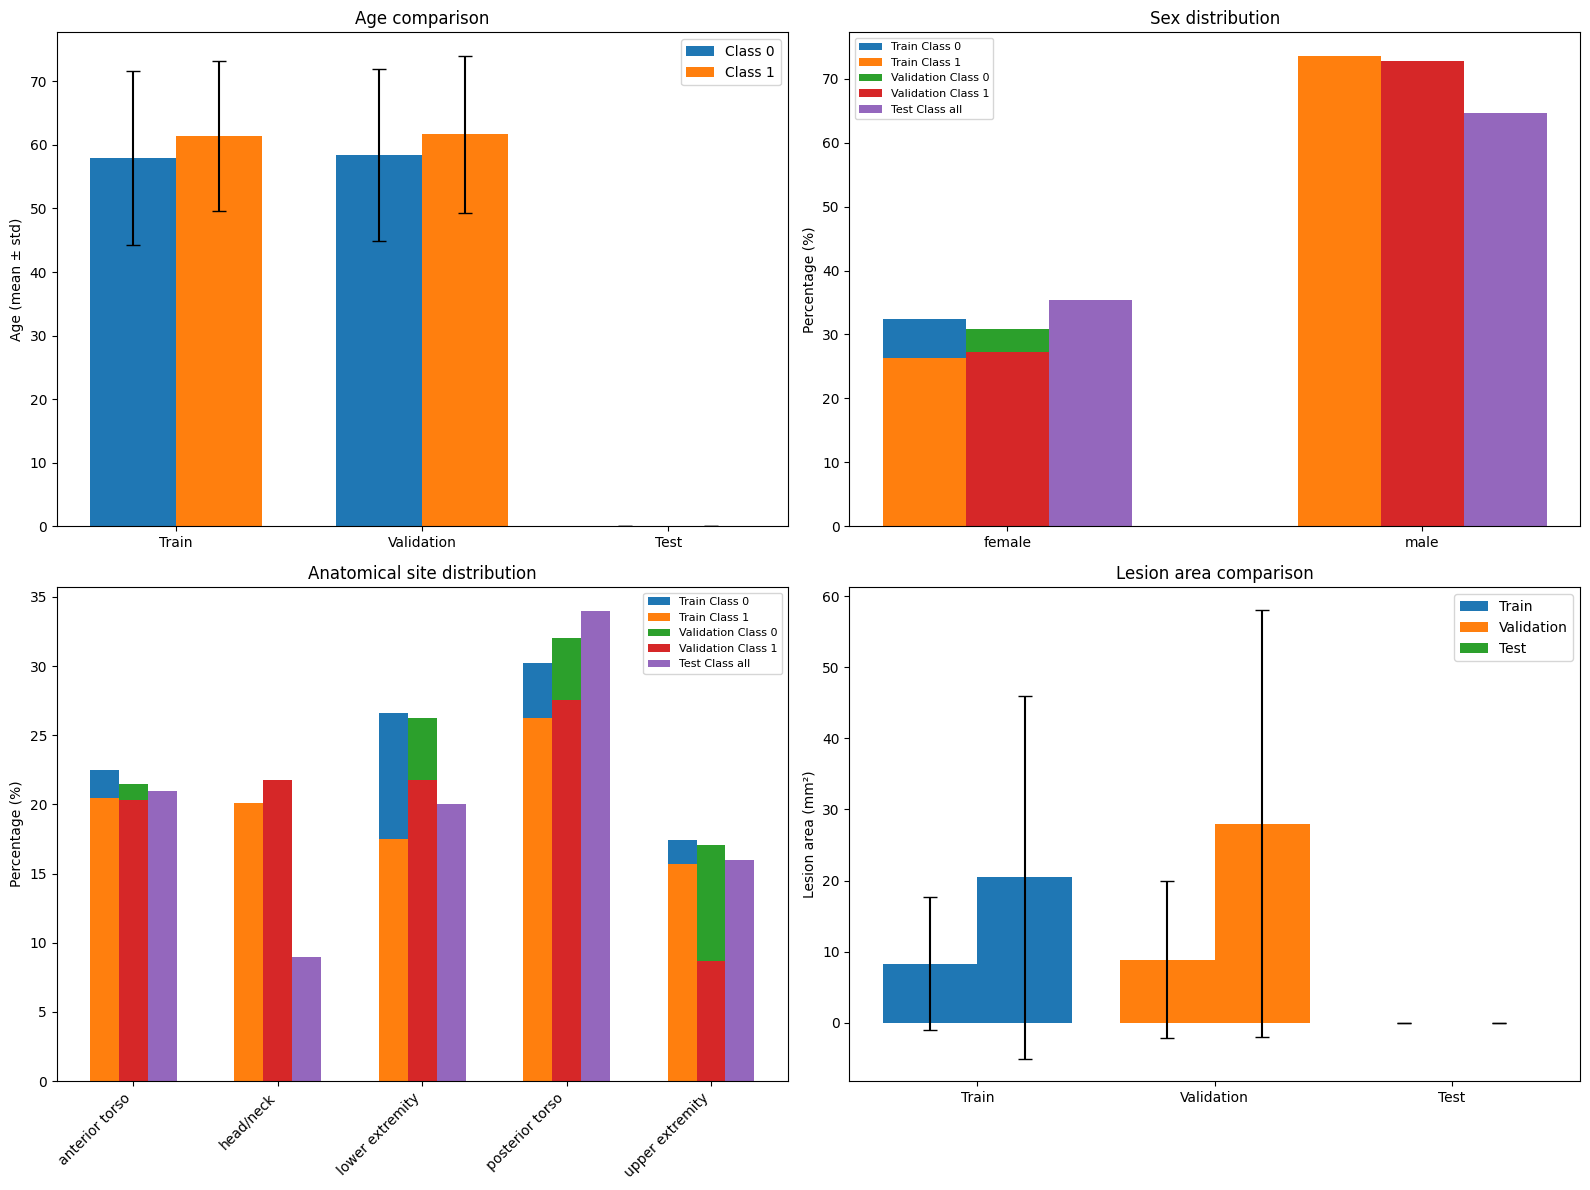

In [74]:
from utils import plot_stats

train_stats = train_dataset.get_dataset_stats(sample_size=300)
val_stats   = val_dataset.get_dataset_stats(sample_size=300)
test_stats  = test_dataset.get_dataset_stats(sample_size=300)
stats_list = [train_stats, val_stats, test_stats]

# Now we compare the analisis of the splits
plot_stats(stats_list)

## DataLoaders

We calculate the **ratio of the weighted sampler** using the formula:
$$
w_{c1}=\frac{p_{target}}{1-p_{target}}\frac{n_{c1}}{n_{c2}}
$$
so in the example we want $ p_{target} = 0.25 $
$$
w_{c1}=\frac{0.25}{0.75}\frac{20}{1}
$$

For the weights of the loss functions is as follows:
$$
pos_w=\frac{1-p_{posImg}}{p_{posImg}}
$$

In [75]:
def make_sampler_weights(targets, p_target):
    n_pos = (targets == 1).sum()
    n_neg = (targets == 0).sum()
    # sampler class weights (w_neg=1)
    w_pos = (p_target / (1 - p_target)) * (n_neg / n_pos)
    class_weights = np.array([1.0, w_pos], dtype=float)
    sample_weights = np.array([class_weights[int(t)] for t in targets], dtype=float)
    
    return sample_weights

In [76]:
from utils import PositiveOversampler
BATCH_SIZE = 32
NUM_IMGS_BATCH = 3000

# Get the weights for the sampler and the BCE loss fucntion
p_target = 0.50
multimodal_train_targets = train_dataset.metadata['target'].values
sample_weights = make_sampler_weights(multimodal_train_targets, p_target)

# Create the weighted sampler with the calculated weights
multimodal_weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=NUM_IMGS_BATCH,
    replacement=True
)

# pos_oversampler = PositiveOversampler(train_dataset, pos_multiplier=4)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=multimodal_weighted_sampler,    # pos_oversampler,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")


📦 Multimodal data loaders created with balanced sampling!


# Backbone

In [77]:
from utils import TrainableModule            

class MetadataMLP(nn.Module):
    def __init__(self, in_features, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(0.3),

            nn.Linear(hidden, hidden//2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden//2),
            nn.Dropout(0.3),

            nn.Linear(hidden//2, hidden//4),
            nn.ReLU(),
            nn.BatchNorm1d(hidden//4),
            nn.Dropout(0.3),
        )
        self.out_dim = hidden//4

    def forward(self, x):
        return self.net(x)
    
class PretrainedClassifier(nn.Module):
    def __init__(self, model_name, model_type, metadata_dim, num_classes=1, pretrained=True):
        super().__init__()
        # Backbone for the image
        if model_type == ".pt":
            self.backbone = torch.load(model_name).to(device)

        elif model_type == "timm":
            self.backbone = timm.create_model(
                model_name,
                pretrained=pretrained,
                num_classes=0  # don't use the original detection head
            )

        # Dummy input to get the real dimension of backbone output
        with torch.no_grad():
            dummy_img = torch.zeros(1, 3, 224, 224)  # ajustar tamaño según tu input
            img_feat = self.backbone(dummy_img)
        self.img_dim = img_feat.shape[1]
        
        # MLP for the metadata
        self.meta_mlp = MetadataMLP(metadata_dim)
        self.meta_dim = self.meta_mlp.out_dim

        # Project metadata up to image feature size
        self.meta_proj = nn.Linear(self.meta_dim, self.img_dim)
        # to nromalize the data 
        self.fusion_norm = nn.LayerNorm(self.img_dim)

        # Gating layer to learn what % of imagen vs metadata usar
        self.gate_layer = nn.Linear(self.img_dim * 2, self.img_dim)

        # Head final (pequeña, robusta)
        self.head = nn.Sequential(
            nn.Linear(self.img_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, image, meta):
        # Image processed by Backbone
        img_feat = self.backbone(image)

        # Metadata processed by MLP
        meta_feat = self.meta_mlp(meta)

        # proyect the meta mlp to a relevant number of features
        meta_proj = self.meta_proj(meta_feat)  # (B, img_dim)

        # Apply a gate to rebalance data 
        gate_input = torch.cat([img_feat, meta_proj], dim=1)  # (B, 2*img_dim)
        gate = torch.sigmoid(self.gate_layer(gate_input))      # (B, img_dim)

        # fusion of both data
        fused = gate * img_feat + (1 - gate) * meta_proj       # (B, img_dim)
        fused = self.fusion_norm(fused)

        # final head
        out = self.head(fused)
        return out

class PretrainedClassifierExtended(PretrainedClassifier, TrainableModule):
    def __init__(self, model_name, model_type, metadata_dim, criterion, device=device,
                 patience=5, min_delta=0.01):
        PretrainedClassifier.__init__(self, model_name, model_type, metadata_dim)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.name = model_name
        self.freeze_backbone()

        # metrics
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):
        print(f"----------------------------------------")
        print(f"       Training {self.name}")
        print(f"----------------------------------------")
        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            start = time.time()
            print(f"Epoch {epoch}/{epochs}: ", end="")

            # freeze, unfreeze layers
            if epoch == 0:
                self.freeze_backbone()
            elif epoch == 6:
                layers2unf = self.get_first_n_backbone_layers(1)
                self.unfreeze_backbone_layers(layers2unf)
                self.optimizer = torch.optim.Adam(
                    filter(lambda p: p.requires_grad, self.parameters()),
                    lr=self.lr)
            elif epoch == 20:
                layers2unf = self.get_first_n_backbone_layers(3)
                self.unfreeze_backbone_layers(layers2unf)
                self.optimizer = torch.optim.Adam(
                    filter(lambda p: p.requires_grad, self.parameters()),
                    lr=self.lr)
            elif epoch == 40:
                self.unfreeze_all()
                self.optimizer = torch.optim.Adam(
                    filter(lambda p: p.requires_grad, self.parameters()),
                    lr=self.lr)


            train_loss, per_pos = self._train_epoch(train_loader, type_input="img")
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos:.3f}%")

            if val_loader:
                val_loss, val_auc = self._validate(val_loader, type_input="img")
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                print(f"Val Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")

                # save the best arquitecture
                if self.best_model_AUC < val_auc:
                    self.best_model_AUC = val_auc
                    self.best_model = copy.deepcopy(self.state_dict())

                if self._check_early_stopping(val_loss):
                    self.load_state_dict(self.best_state_dict)
                    self.to(self.device)
                    return  # exit for early stopping
                
            torch.cuda.synchronize()
            print(f" in {time.time() - start:.2f}s")
    
    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone_layers(self, layer_name_list):
        """
        layer_name_list: list[str] names of the layers,
        ej.: ["blocks.6", "stages.3"]
        """
        for name, param in self.backbone.named_parameters():
            if any(name.startswith(layer) for layer in layer_name_list):
                param.requires_grad = True
        print("Unfrozen:", layer_name_list)
    
    def unfreeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
    
    def get_first_n_backbone_layers(self, n=2):
        layer_names = []
        for name, _ in self.backbone.named_parameters():
            layer_names.append(name)

        # Remove duplicated layers
        layer_names = list(dict.fromkeys(layer_names))

        ordered_block_names = []
        for name, _ in self.backbone.named_parameters():
            block = name.split('.')[0]
            if block not in ordered_block_names:
                ordered_block_names.append(block)

        return ordered_block_names[:n]
    
    @classmethod
    def load(cls, path, model_name, metadata_dim, criterion, device):
        model = cls(model_name, metadata_dim, criterion, device)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        return model


### Now we wrap the ensemble and models with a train function

In [78]:
class EnsembleClassifier(nn.Module):
    def __init__(self, models, models_type, hidden_dim=64):
        super().__init__()

        # Freeze base models
        self.models = nn.ModuleList(models)
        self.num_models = len(models)
        for m in self.models:
            for p in m.parameters():
                p.requires_grad = False
            m.eval()

        self.models_type = models_type

        # get the number and propierties of models
        output_dims = [
            self.get_output_dim(m, t, device) 
            for m, t in zip(self.models, self.models_type)
        ]

        self.meta_input_dim = sum(output_dims)

        # ------------ Meta-model ("stacker") ----------------
        self.meta_model = nn.Sequential(
            nn.Linear(self.meta_input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    # ---------------------------------------------------------
    def forward(self, image, metadata):

        base_preds = []
        for m, mtype in zip(self.models, self.models_type):
            if mtype == "mix":
                preds = m(image, metadata)      # (batch, 1)
            elif mtype == "img":
                preds = m(image)
            elif mtype == "meta":
                preds = m(metadata)
            else:
                raise ValueError(f"Invalid type_input: {metadata}")
            
            if preds is None:
                raise RuntimeError("ERROR: A model returned None.")

            
            base_preds.append(preds)

        # concatenate the logits: shape → (batch, num_models)
        base_preds = torch.cat(base_preds, dim=1)

        # Process the model
        out = self.meta_model(base_preds)
        return out

    def get_output_dim(self, model, mtype, device):
        """Run a single dummy forward pass to infer output dimension."""
        
        model.eval()

        with torch.no_grad():
            if mtype == "img":
                dummy_img = torch.randn(1, 3, 224, 224).to(device)
                out = model(dummy_img)

            elif mtype == "meta":
                dummy_meta = torch.randn(1, self.metadata_dim).to(device)
                out = model(dummy_meta)

            elif mtype == "mix":
                dummy_img = torch.randn(1, 3, 224, 224).to(device)
                dummy_meta = torch.randn(1, self.metadata_dim).to(device)
                out = model(dummy_img, dummy_meta)

            else:
                raise ValueError("Invalid model type")
        
        return out.view(1, -1).shape[1]

In [79]:
from utils import TrainableModule
from sklearn.metrics import roc_auc_score


class EnsembleClassifierExtended(EnsembleClassifier, TrainableModule):
    def __init__(self, models, models_type, criterion, device=device,
                 patience=10, min_delta=0.01, num_epoc_val=5):
        EnsembleClassifier.__init__(self, models, models_type)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.val_epoc = num_epoc_val
        # metrics
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": [],
            "ensembles_val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
            start = time.time()
            print(f"\nEpoch {epoch}/{epochs}: ", end="")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos}%")


            if val_loader and epoch%self.val_epoc==0:
                val_loss, val_auc, ensemble_aucs = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                self.history["ensembles_val_auc"].append(ensemble_aucs)
                print(f"\tVal Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")

                # save the best arquitecture
                if self.best_model_AUC < val_auc:
                    self.best_model_AUC = val_auc
                    self.best_model = copy.deepcopy(self.state_dict())

                if self._check_early_stopping(val_loss):
                    self.load_state_dict(self.best_state_dict)
                    self.to(self.device)
                    return  # exit for early stopping
                
            torch.cuda.synchronize()
            print(f" in {time.time() - start:.2f}s")

    def _validate(self, loader):
        self.eval()
        total_loss = 0
        preds_list = []
        labels_list = []
        model_aucs = []

        with torch.no_grad():
            # calculate each model in ensemble roc auc
            for model, m_type in zip(self.models, self.models_type):
                model.eval()
                preds_model = []
                labels_model = []
                for images, metadata, labels, _ in loader:
                    images = images.to(self.device, non_blocking=True)
                    metadata = metadata.to(self.device, non_blocking=True)
                    labels = labels.float().to(self.device, non_blocking=True)

                    with amp.autocast(device_type=self.device.type):  # AMP
                        logits = self.forward_single(model, m_type, images, metadata)
                        probs = torch.sigmoid(logits)              # (B, K)
                        probs = probs.mean(dim=1)                  # (B,)  ← una predicción por imagen

                        preds_model.extend(probs.cpu().numpy().tolist())
                        labels_model.extend(labels.cpu().numpy().tolist())

                preds_model = np.array(preds_model)
                labels_model = np.array(labels_model)
                auc = roc_auc_score(labels_model, preds_model)
                model_aucs.append(auc)
            
            # calculate the combined roc auc
            for images, metadata, labels, _ in loader:
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)
                labels = labels.float().to(self.device, non_blocking=True)

                with amp.autocast(device_type=self.device.type):  # AMP
                    preds = self(images, metadata).squeeze()
                    loss = self.criterion(preds, labels)
                total_loss += loss.item()

                preds_list.append(preds.cpu())
                labels_list.append(labels.cpu())

        # update ensemble weights
        self.weights_ens = [a / sum(model_aucs) for a in model_aucs]

        preds = torch.cat(preds_list).sigmoid().numpy()
        labels = torch.cat(labels_list).numpy()
        auc_ensemble = roc_auc_score(labels, preds)

        return total_loss / len(loader), auc_ensemble, model_aucs
    
    def forward_single(self, model, mtype, images, metadata):
        if mtype == "img":
            return model(images)
        elif mtype == "meta":
            return model(metadata)
        elif mtype == "mix":
            return model(images, metadata)
        else:
            raise ValueError(f"Invalid model type: {mtype}")

    # -------------------------------------------------------------
    def submit_kaggle(self, test_loader, submission_file="submission.csv"):
        """
        Generate Kaggle submission CSV using ensemble predictions.

        Parameters:
        -----------
        test_loader : DataLoader
            Test dataset loader. Should yield (images, metadata, isic_ids) or (images, isic_ids)
        submission_file : str
            Output CSV filename

        Returns:
        --------
        submission_df : pd.DataFrame
            DataFrame containing 'isic_id' and 'target' columns
        """
        self.eval()
        predictions = []

        with torch.no_grad():
            for images, metadata, isic_ids in tqdm(test_loader, desc="Inference on Test"):
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)

                with amp.autocast(device_type=self.device.type):  # AMP
                    logits = self(images, metadata).squeeze()
                    probs = torch.sigmoid(logits)
                
                probs = probs.cpu().numpy()
                for isic_id, p in zip(isic_ids, probs):
                    predictions.append({"isic_id": isic_id, "target": float(p)})

        submission_df = pd.DataFrame(predictions)
        submission_df = submission_df.sort_values(by="isic_id").reset_index(drop=True)

        submission_file = "submission.csv"
        submission_df.to_csv(submission_file, index=False)

        print(f"Saved submission with {len(submission_df)} rows to {submission_file}")
        display(submission_df.head(10))

    # -------------------------------------------------------------
    @classmethod
    def load(cls, path, model_name, metadata_dim, criterion, device):
        model = cls(model_name, metadata_dim, criterion, device)
        model.load_state_dict(torch.load(path, map_location=device))
        model.to(device)
        return model


# Train

In [80]:
from sklearn.metrics import roc_auc_score
def evaluate_model_auc(model, val_loader, device):
    model.eval()
    probs_list, labels_list = [], []
    with torch.no_grad():
        for batch in val_loader:
            images, metadata, labels, _ = batch
            images = images.to(device, non_blocking=True)
            metadata = metadata.to(device, non_blocking=True)
            logits = model(images, metadata).squeeze()
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_list.append(probs)
            labels_list.append(labels.numpy())
    probs = np.concatenate(probs_list)
    labels = np.concatenate(labels_list)
    return roc_auc_score(labels, probs), labels, probs

def grid_search_posweight_p_target(
    ModelClass,                # class factory to instantiate model (e.g. PretrainedClassifierExtended)
    model_kwargs,              # kwargs for model instantiation (except criterion/device)
    train_dataset, val_dataset,
    pos_weight_grid,          # list of scalar pos_weight candidates (for BCE)
    p_target_grid,            # list of target positive fractions per epoch (e.g. [0.05,0.1,0.25])
    epochs_per_trial=2,
    batch_size=32,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    verbose=True
):
    best = {"auc": -1, "pos_weight": None, "p_target": None, "history": None}
    # extract raw targets from train metadata (np array)
    train_targets = train_dataset.metadata["target"].values

    for p_target in p_target_grid:
        # build sample_weights once per p_target
        sample_weights = make_sampler_weights(train_targets, p_target)

        # create sampler: choose epoch_size (num samples per epoch). Use len(train_dataset) or smaller.
        epoch_num_samples = int(len(train_dataset)/2)  # you can reduce this to speed up search
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=epoch_num_samples, replacement=True)

        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, sampler=sampler, 
            num_workers=4, pin_memory=(device.type=="cuda"), drop_last=True,
        )
        val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                                shuffle=False, num_workers=4, 
                                pin_memory=(device.type=="cuda"),
                                drop_last=True)

        for pos_w in pos_weight_grid:
            if verbose:
                print(f"\nTrial: p_target={p_target:.3f}, pos_weight={pos_w}")

            # Build criterion with pos_weight (PyTorch expects a tensor)
            pos_weight_tensor = torch.tensor(pos_w, dtype=torch.float32).to(device)
            criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

            # Instantiate a fresh model for this trial
            # ModelClass must accept (model_name, metadata_dim, criterion, device, patience) or be adapted.
            trial_kwargs = dict(model_kwargs)  # shallow copy
            trial_kwargs.update(dict(criterion=criterion, device=device))
            model = ModelClass(**trial_kwargs)

            # Train briefly
            model.fit(train_loader, val_loader=None, epochs=epochs_per_trial)  # or pass val_loader to track val loss inside fit

            # Evaluate on validation
            auc, labels_val, probs_val = evaluate_model_auc(model, val_loader, device)
            if verbose:
                print(f"Validation AUC: {auc:.4f} for loss_weight: {pos_w}, por_target: {p_target}")

            # Save best
            if auc > best["auc"]:
                best.update({
                    "auc": auc,
                    "pos_weight": pos_w,
                    "p_target": p_target,
                    "model_state": copy.deepcopy(model.state_dict()),
                    "labels": labels_val,
                    "probs": probs_val
                })

            # free GPU memory
            del model
            torch.cuda.empty_cache()

    return best

In [81]:
num_metadata_features = test_dataset.metadata_features.shape[1]

model_kwargs = {
    "model_name": "efficientnet_b0",
    "metadata_dim": num_metadata_features,
    "patience": 3,
    "min_delta": 1e-4
}

# min max values for loss class weights
pos_weight_loss = (1-(1/NEG_RATIO))/(1/NEG_RATIO)
pos_weight_grid = np.linspace(12, NEG_RATIO, 2)

# min max values for 
p_target_grid = np.linspace(0.5, 0.6, 2)

# best = grid_search_posweight_p_target(
#     PretrainedClassifierExtended,
#     model_kwargs,
#     train_dataset,
#     val_dataset,
#     pos_weight_grid,
#     p_target_grid,
#     epochs_per_trial=5,
#     batch_size=64,
#     device=device,
#     verbose=True
# )

# print("BEST:", best["auc"], best["p_target"], best["pos_weight"])

In [82]:
import timm
print(timm.list_models())

['aimv2_1b_patch14_224', 'aimv2_1b_patch14_336', 'aimv2_1b_patch14_448', 'aimv2_3b_patch14_224', 'aimv2_3b_patch14_336', 'aimv2_3b_patch14_448', 'aimv2_huge_patch14_224', 'aimv2_huge_patch14_336', 'aimv2_huge_patch14_448', 'aimv2_large_patch14_224', 'aimv2_large_patch14_336', 'aimv2_large_patch14_448', 'bat_resnext26ts', 'beit3_base_patch16_224', 'beit3_giant_patch14_224', 'beit3_giant_patch14_336', 'beit3_large_patch16_224', 'beit_base_patch16_224', 'beit_base_patch16_384', 'beit_large_patch16_224', 'beit_large_patch16_384', 'beit_large_patch16_512', 'beitv2_base_patch16_224', 'beitv2_large_patch16_224', 'botnet26t_256', 'botnet50ts_256', 'caformer_b36', 'caformer_m36', 'caformer_s18', 'caformer_s36', 'cait_m36_384', 'cait_m48_448', 'cait_s24_224', 'cait_s24_384', 'cait_s36_384', 'cait_xs24_384', 'cait_xxs24_224', 'cait_xxs24_384', 'cait_xxs36_224', 'cait_xxs36_384', 'coat_lite_medium', 'coat_lite_medium_384', 'coat_lite_mini', 'coat_lite_small', 'coat_lite_tiny', 'coat_mini', 'coat_s

efficientnet_b4,
efficientnet_b0,
resnet18,
resnet50,
vgg13,
vgg16,
vit_tiny_patch16_224.augreg_in21k_ft_in1k

In [ ]:
# now we create the models for the train
num_metadata_features = test_dataset.metadata_features.shape[1]

#-------------------------------------------------------------------------------
# 1º Define & train the models of the ensemble
#-------------------------------------------------------------------------------
# Importance of each class is calculated using n-neg/n_pos = (1-1/ratio)/(1/ratio)
pos_weight_loss = 3
criterion = nn.BCEWithLogitsLoss()# pos_weight=torch.tensor(pos_weight_loss).to(device)) 
# model_names = ["efficient_net_f0", "efficient_net_f1", "efficient_net_f2", "efficient_net_f3", "efficient_net_f4"]
# model_types = [".pt", ".pt", ".pt", ".pt", ".pt"]
# model_list= []
# NUM_EPOCH = 60

# for i, model_name in enumerate(model_names):
#     model_path = f"{MODELS_DIR}/raw_models/{model_name}.pt"

#     if model_name+".pt" not in os.listdir(MODELS_DIR):
#         model = PretrainedClassifierExtended(
#             model_path, 
#             metadata_dim=num_metadata_features,
#             model_type=model_types[i],
#             criterion=criterion,
#             device=device,
#             patience=NUM_EPOCH)
#         model.fit(train_loader, valid_loader, epochs=NUM_EPOCH)
#         # save the model trained
#         model.save(model_path)

#     else: # load from memory
#         print(f"model {model_path} loaded from memory")
#         model = PretrainedClassifierExtended(
#             model_name=model_names[i], 
#             metadata_dim=num_metadata_features,
#             criterion=criterion,
#             device=device)
#         model.load(model_path)

#     model_list.append(model)

/tmp/ipykernel_4300/4017172071.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.backbone = torch.load(model_name).to(device)
/home/pawn/anaconda3/envs/aprendizaje/l

RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript, serialized code (most recent call last):
  File "code/__torch__/models.py", line 23, in forward
    _0 = getattr(dropouts3, "0")
    enet = self.enet
    _5 = torch.squeeze((enet).forward(x, ), -1)
                        ~~~~~~~~~~~~~ <--- HERE
    input = torch.squeeze(_5, -1)
    _6 = (_0).forward(input, )
  File "code/__torch__/geffnet/gen_efficientnet.py", line 26, in forward
    bn1 = self.bn1
    conv_stem = self.conv_stem
    _0 = (bn1).forward((conv_stem).forward(x, ), )
                        ~~~~~~~~~~~~~~~~~~ <--- HERE
    _1 = (blocks).forward((act1).forward(_0, ), )
    _2 = (bn2).forward((conv_head).forward(_1, ), )
  File "code/__torch__/geffnet/conv2d_layers.py", line 34, in forward
    _16 = [_10, _12, _14, int(torch.sub(pad_h, _15))]
    x0 = torch.pad(x, _16)
    input = torch._convolution(x0, weight, None, [2, 2], [0, 0], [1, 1], False, [0, 0], 1, False, False, T

In [ ]:
#-------------------------------------------------------------------------------
# 2º Define the parámeters and the enseble 
#-------------------------------------------------------------------------------
model_name = "Ensemble"

model_names = ["efficient_net_f0", 
               "efficient_net_f1", 
               "efficient_net_f2", 
               "efficient_net_f3", 
               "efficient_net_f4"]

models_paths = [MODELS_DIR / (name + '.pt') for name in model_names]

def load_models(paths):
    models = []
    for path in paths:
        model = torch.jit.load(path, map_location=device)
        models.append(model)

    return models

models = load_models(models_paths)

print("\n/////////////////// FITTING ENSEMBLE  ///////////////////\n")
ensemble_class = EnsembleClassifierExtended(
                    models=models,
                    models_type=["img", "img", "img"],
                    criterion=criterion,
                    device=device, 
                    min_delta=1e-4,
                    patience=NUM_EPOCH)

ensemble_class.fit(train_loader, valid_loader, epochs=NUM_EPOCH)
# save the model trained
ensemble_class.save(model_path)

# if model_name+".pth" not in os.listdir(MODELS_DIR):

# else: # load from memory
#     print(f"model {model_path} loaded from memory")
#     model = PretrainedClassifierExtended(
#         model_name=model_names[i], 
#         metadata_dim=num_metadata_features,
#         criterion=criterion,
#         device=device)
#     model.load(model_path)


/////////////////// FITTING ENSEMBLE  ///////////////////



/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:462: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = amp.GradScaler() if device.type == "cuda" else None



Epoch 1/60: 

Train loss: 0.7640 || percentaje pos in epoch: 0.5003333333333333%
 in 44.71s

Epoch 2/60: 

Train loss: 0.7242 || percentaje pos in epoch: 0.49766666666666665%
 in 36.84s

Epoch 3/60: 

...

Train loss: 0.6507 || percentaje pos in epoch: 0.5133333333333333%
 in 30.25s

Epoch 29/60: 

Train loss: 0.6551 || percentaje pos in epoch: 0.5056666666666667%
 in 31.35s

Epoch 30/60: 

Train loss: 0.6480 || percentaje pos in epoch: 0.49566666666666664%
	Val Loss: 0.6761 | AUC: 0.6422 in 95.28s

Epoch 31/60: 

Train loss: 0.6526 || percentaje pos in epoch: 0.507%
 in 32.55s

Epoch 32/60: 

KeyboardInterrupt: 

### Plot the results of the train

In [ ]:
# conffusion matrix of all models and the ensemble
n_models = len(model_names)
total_plots = n_models + 1  # including ensemble

fig, axes = plt.subplots(1, total_plots, figsize=(5*total_plots, 5))

# Plot individual models
for i, model in enumerate(model_list):
    labels, preds, _ = model.pred_probs(valid_loader)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d')
    axes[i].set_title(model_names[i])

# Plot ensemble
labels, preds, _ = ensemble_class.pred_probs(valid_loader)
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(ax=axes[-1], cmap=plt.cm.Blues, values_format='d')
axes[-1].set_title("Ensemble")

plt.tight_layout()
plt.show()

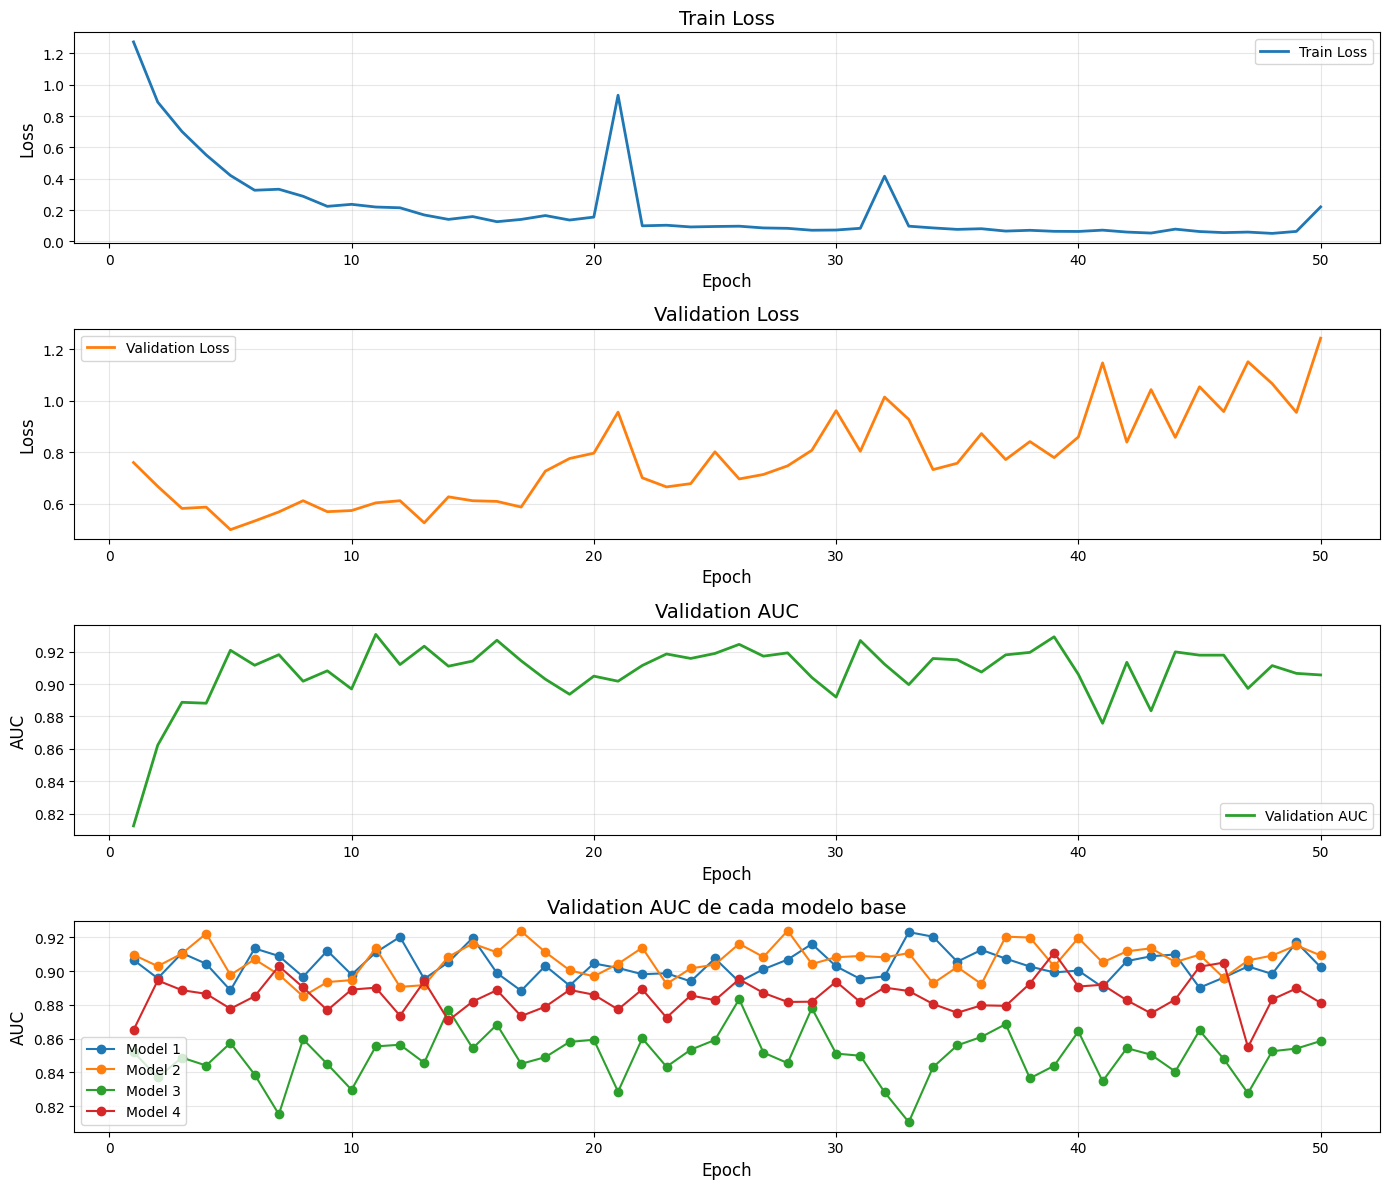

In [ ]:
train_loss = ensemble_class.history["train_loss"]
val_loss = ensemble_class.history["val_loss"]
val_auc = ensemble_class.history["val_auc"]
ensemble_model_aucs = ensemble_class.history.get("ensembles_val_auc", [])

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(14, 12))

# 1. TRAIN LOSS
plt.subplot(4, 1, 1)
plt.plot(epochs, train_loss, label="Train Loss", color="tab:blue", linewidth=2)
plt.title("Train Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 2. VALIDATION LOSS
plt.subplot(4, 1, 2)
plt.plot(epochs, val_loss, label="Validation Loss", color="tab:orange", linewidth=2)
plt.title("Validation Loss", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

# 3. VALIDATION AUC
plt.subplot(4, 1, 3)
plt.plot(epochs, val_auc, label="Validation AUC", color="tab:green", linewidth=2)
plt.title("Validation AUC", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(4, 1, 4)
if ensemble_model_aucs:
    ensemble_model_aucs = np.array(ensemble_model_aucs)  # shape [epochs, n_models]
    n_models = ensemble_model_aucs.shape[1]
    for i in range(n_models):
        plt.plot(epochs, ensemble_model_aucs[:, i], marker='o', label=f'Model {i+1}')
    plt.title("Validation AUC de cada modelo base", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("AUC", fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

### kaggle submission generation

In [ ]:
ensemble_class.submit_kaggle(test_loader, submission_file="submission.csv")

Inference on Test:   0%|          | 0/2 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x76 and 77x128)